In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import START_DATE, END_DATE, extent_to_rd, extent_to_ee
import numpy as np

hpd.util.get_color_logger("INFO")

# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)

<RootLogger root (INFO)>

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = extent_to_rd() 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 12
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|██████████| 12/12 [00:19<00:00,  1.62s/it]


In [4]:
oc.plots.interactive_map(
    color="red",
    zoom_start=15,
    tiles="Esri.WorldImagery",
    popup_width=350
)

In [5]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs,lat,lon
name,,,,,,,,,,,,,,,
GMW000000037926001,93189.909294,440646.828947,130571-99,,lizard,m NAP,1,-2.91,-4.91,-2.21,-2.41,True,GroundwaterObs GMW000000037926001 -----metadat...,51.950824,4.488096
GMW000000037928001,93169.289120,440666.928770,130571-98,,lizard,m NAP,1,-2.82,-4.82,-2.30,-2.32,True,GroundwaterObs GMW000000037928001 -----metadat...,51.951002,4.487792
GMW000000037937001,93118.429424,440492.229166,130571-96,,lizard,m NAP,1,-2.58,-4.58,-2.05,-2.08,True,GroundwaterObs GMW000000037937001 -----metadat...,51.949427,4.487084
GMW000000037939001,93213.649008,440628.729056,130571-100,,lizard,m NAP,1,-2.54,-4.54,-1.89,-2.04,True,GroundwaterObs GMW000000037939001 -----metadat...,51.950664,4.488444
GMW000000037940001,93283.319334,440695.628872,130571-102,,lizard,m NAP,1,-2.56,-4.56,-1.99,-2.06,True,GroundwaterObs GMW000000037940001 -----metadat...,51.951273,4.489446
GMW000000037941001,93234.359551,440659.228510,130571-101,,lizard,m NAP,1,-2.66,-4.66,-1.97,-2.16,True,GroundwaterObs GMW000000037941001 -----metadat...,51.950940,4.488740
GMW000000102664001,93153.539532,440540.226751,130571-9,,lizard,m NAP,1,-3.09,-4.09,-2.03,-2.09,True,GroundwaterObs GMW000000102664001 -----metadat...,51.949862,4.487586
GMW000000102816001,93154.459512,440540.706721,130571-92,,lizard,m NAP,1,-3.06,-5.06,-1.99,-2.06,True,GroundwaterObs GMW000000102816001 -----metadat...,51.949866,4.487599
GMW000000102876001,93352.969418,440644.496010,130571-93,,lizard,m NAP,1,-2.80,-4.80,-2.27,-2.30,True,GroundwaterObs GMW000000102876001 -----metadat...,51.950821,4.490468


In [6]:
gw = oc.obs["GMW000000037940001"]
print(gw)

GroundwaterObs GMW000000037940001
-----metadata------
name : GMW000000037940001 
x : 93283.31933403443 
y : 440695.62887220015 
location : 130571-102 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -2.56 
screen_bottom : -4.5600000000000005 
ground_level : -1.99 
tube_top : -2.06 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2015-05-22 23:00:00  -3.65   NaN  Gemeten   hand
2015-07-29 23:00:00  -3.65   NaN  Gemeten   hand
2015-08-13 23:00:00  -3.65   NaN  Gemeten   hand
2015-10-18 23:00:00  -3.43   NaN  Gemeten   hand
2015-11-04 10:35:00  -3.47   NaN  Gemeten   hand
...                    ...   ...      ...    ...
2026-01-06 05:27:13  -2.81   2.0           diver
2026-01-06 09:27:15  -2.81   2.0           diver
2026-01-06 13:27:17  -2.83   2.0           diver
2026-01-06 17:27:18  -2.82   2.0           diver
2026-01-07 09:27:25  -2.84   2.0           diver

[7026 

In [7]:
ts = gw["value"].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.dropna()

print(ts.index.min(), ts.index.max())
print(ts.shape)

2015-05-22 23:00:00 2026-01-07 09:27:25
(7015,)


In [8]:
ts_year = ts.loc[START_DATE:END_DATE]

ts_daily_raw = ts_year.resample("D").mean()

ts_daily = ts_daily_raw.interpolate(method="time")

is_interpolated = ts_daily_raw.isna()

In [9]:
percentile = 0.30

# === FIXED THRESHOLD ===
threshold_fixed = ts_year.quantile(percentile)

# === VARIABLE THRESHOLD ===
monthly_threshold = (
    ts_year
    .groupby(ts_year.index.month)
    .quantile(percentile)
    .reindex(range(1, 13))          # zorg dat alle maanden bestaan
)

n_months_with_data = monthly_threshold.notna().sum()

if n_months_with_data < 6:
    print(
        f"Not enough data for variable threshold ({n_months_with_data} months). "
        "Variable threshold will not be used."
    )
    threshold_variable_smooth = None
else:
    monthly_threshold = monthly_threshold.interpolate(method="linear")

    threshold_variable = ts_daily.index.to_series().map(
        lambda d: monthly_threshold.loc[d.month]
    )

    threshold_variable_smooth = (
        threshold_variable
        .rolling(window=20, min_periods=1)
        .mean()
    )

# === KIES welke threshold wordt gebruikt voor DROOGTE ===
threshold = threshold_variable_smooth if threshold_variable_smooth is not None else threshold_fixed


In [10]:
is_drought_fixed = ts_daily < threshold_fixed

if threshold_variable_smooth is not None:
    is_drought_variable = ts_daily < threshold_variable_smooth
else:
    is_drought_variable = None

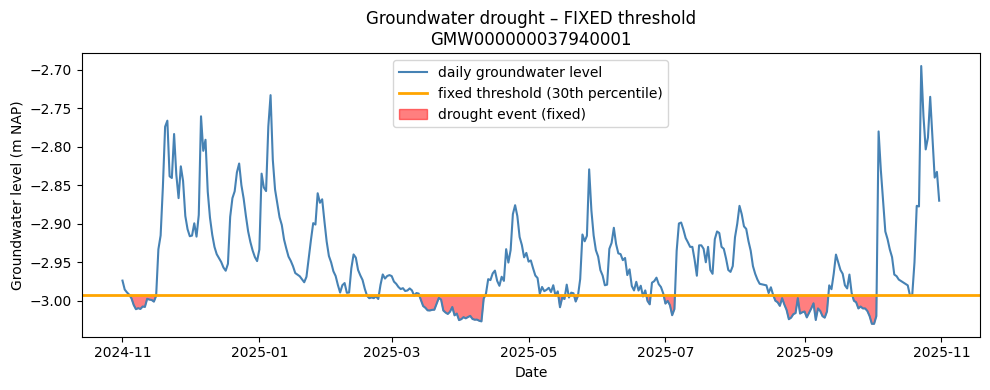

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    ts_daily.index,
    ts_daily,
    color="steelblue",
    linewidth=1.5,
    label="daily groundwater level",
)

ax.axhline(
    threshold_fixed,
    color="orange",
    linewidth=2,
    linestyle="-",
    label="fixed threshold (30th percentile)",
)

ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold_fixed,
    where=is_drought_fixed,
    color="red",
    alpha=0.5,
    label="drought event (fixed)",
    interpolate=True,
)

ax.set_ylabel("Groundwater level (m NAP)")
ax.set_xlabel("Date")
ax.set_title(f"Groundwater drought – FIXED threshold\n{gw.name}")
ax.legend()

plt.tight_layout()
plt.show()


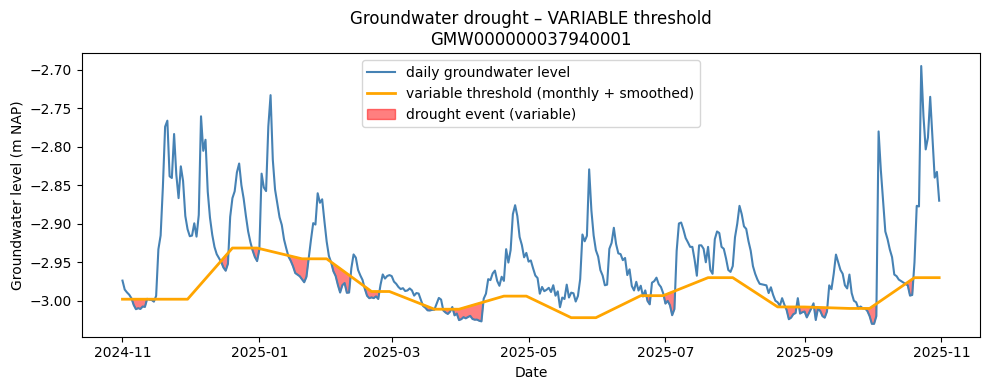

In [12]:
if threshold_variable_smooth is not None:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        ts_daily.index,
        ts_daily,
        color="steelblue",
        linewidth=1.5,
        label="daily groundwater level",
    )

    ax.plot(
        threshold_variable_smooth.index,
        threshold_variable_smooth.values,
        color="orange",
        linewidth=2,
        label="variable threshold (monthly + smoothed)",
    )

    ax.fill_between(
        ts_daily.index,
        ts_daily,
        threshold_variable_smooth,
        where=is_drought_variable,
        color="red",
        alpha=0.5,
        label="drought event (variable)",
        interpolate=True,
    )

    ax.set_ylabel("Groundwater level (m NAP)")
    ax.set_xlabel("Date")
    ax.set_title(f"Groundwater drought – VARIABLE threshold\n{gw.name}")
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Variable threshold plot skipped: insufficient data.")


In [13]:
# =========================
# SAMENVATTING – FIXED THRESHOLD
# =========================
duration_fixed = is_drought_fixed.sum()
max_deficit_fixed = (threshold_fixed - ts_daily[is_drought_fixed]).max()

n_interpolated = is_interpolated.sum()

print("=== FIXED THRESHOLD (30th percentile) ===")
print(
    f"Drought duration (2024–2025): {duration_fixed} days. "
    f"{n_interpolated} days were interpolated."
)
print(f"Maximum deficit (2024–2025): {max_deficit_fixed:.2f} m\n")


# =========================
# SAMENVATTING – VARIABLE THRESHOLD
# =========================
if is_drought_variable is not None:
    duration_variable = is_drought_variable.sum()
    max_deficit_variable = (
        threshold_variable_smooth - ts_daily[is_drought_variable]
    ).max()

    print("=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===")
    print(
        f"Drought duration (2024–2025): {duration_variable} days. "
        f"{n_interpolated} days were interpolated."
    )
    print(f"Maximum deficit (2024–2025): {max_deficit_variable:.2f} m\n")
else:
    print("=== VARIABLE THRESHOLD ===")
    print("Not enough data to compute variable threshold.\n")


# =========================
# DAGELIJKS OVERZICHT (WAARDES + HERKOMST)
# =========================
origin_per_day = (
    gw[["value", "origin"]]
    .dropna()
    .assign(date=lambda df: df.index.normalize())
    .groupby("date")["origin"]
    .agg(lambda x: ",".join(sorted(set(x))))
)

summary = pd.DataFrame({
    "value": ts_daily,
    "interpolated": is_interpolated,
})

summary["origin"] = origin_per_day
summary.loc[summary["interpolated"], "origin"] = "interpolated"

summary


=== FIXED THRESHOLD (30th percentile) ===
Drought duration (2024–2025): 99 days. 6 days were interpolated.
Maximum deficit (2024–2025): 0.04 m

=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===
Drought duration (2024–2025): 99 days. 6 days were interpolated.
Maximum deficit (2024–2025): 0.03 m



,value,interpolated,origin
peil_datum_tijd,,,
2024-11-01,-2.973833,False,diver_validated
2024-11-02,-2.985500,False,diver_validated
2024-11-03,-2.989167,False,diver_validated
2024-11-04,-2.992167,False,diver_validated
2024-11-05,-2.996833,False,diver_validated
...,...,...,...
2025-10-27,-2.735000,False,diver
2025-10-28,-2.786667,False,diver
2025-10-29,-2.840000,False,diver
